# AlohaMini：本地 ACT／AM-ACT

本地数据 → 时间与图像检查 → 训练样本 → 单批次损失 → 训练 → 离线预测。ACT 和 AM-ACT 共用此流程。

按顺序运行。数据警告会显示但不要求填写确认文字；数据损坏仍会报错。训练和真机执行默认关闭，Notebook 调用平台正式库，不另写控制或训练实现。

In [9]:
import json
from pathlib import Path

from alohamini.paths import WorkspacePaths

config_path = Path('act.json')
if not config_path.exists():
    config_path = Path('examples/learning/act.json')
settings = json.loads(config_path.read_text())
# 在 act.json 中设置 dataset、policy、train_episodes、val_episodes 和 state。
# policy 可选 act / am_act；训练与验证使用不同 episode。
settings['dataset'] = str(Path(settings['dataset']).expanduser().resolve())
print('数据集:', settings['dataset'])
print('策略:', settings['policy'], '训练:', settings['train_episodes'], '验证:', settings.get('val_episodes', []))
CHECKPOINT = WorkspacePaths().run(settings['run_name']) / 'checkpoint'
RUN_TRAINING = True
ENABLE_ROBOT = False
HOST = None

数据集: /home/anncatto/Alohamini_workspace/datasets/task_demo_del
策略: act 训练: [0, 1, 2, 3, 4, 5, 6] 验证: [7]


## 1. 数据有效性与配对

`safety.jsonl` 保留原始 Host 采集时间，Parquet 的 `timestamp` 是帧号 / 录制 FPS。下面区分帧间隔抖动、累计时间漂移和 state/图像配对误差；累计漂移不等于同样大小的图像/action 错配。

录制可用 `--fps 25 --display_data` 留出采样余量并开启 Rerun；控制仍为 50 Hz，相机配置不变。不要通过修改已有数据的 FPS 消除警告。

In [2]:
from alohamini.datasets.tools import check_dataset

report = check_dataset(settings['dataset'], decode_images=True)
print('数据规模:', report['summary'])
print('错误:', report['errors'], '警告:', report['warnings'])
for issue in report['issues']:
    print(f"[{issue['severity']}] {issue['code']}: {issue['message']}")
if not report['valid']:
    raise ValueError('数据结构或内容检查失败，请先处理上面的 errors。')

数据规模: {'episodes': 8, 'frames': 1153, 'pending_episodes': 0}
错误: 0 警告: 10
[warning] SAFETY_CAMERA_GAP: Episode 0: wrist_right has gaps/repeated frames
[warning] SAFETY_CAPTURE_TIMEBASE: Episode 0: physical acquisition differs from the fixed-FPS timeline by up to 0.098s; temporal resampling or segmentation requires review
[warning] SAFETY_CAPTURE_TIMEBASE: Episode 1: physical acquisition differs from the fixed-FPS timeline by up to 0.082s; temporal resampling or segmentation requires review
[warning] SAFETY_CAPTURE_TIMEBASE: Episode 2: physical acquisition differs from the fixed-FPS timeline by up to 0.080s; temporal resampling or segmentation requires review
[warning] SAFETY_CAPTURE_TIMEBASE: Episode 3: physical acquisition differs from the fixed-FPS timeline by up to 0.082s; temporal resampling or segmentation requires review
[warning] SAFETY_CAMERA_GAP: Episode 4: wrist_right has gaps/repeated frames
[warning] SAFETY_CAPTURE_TIMEBASE: Episode 4: physical acquisition differs from the 

Episode 0: 144 帧, 目标 30 FPS, 首尾实测 29.40 FPS
Episode 1: 145 帧, 目标 30 FPS, 首尾实测 29.49 FPS
Episode 2: 144 帧, 目标 30 FPS, 首尾实测 29.51 FPS
Episode 3: 144 帧, 目标 30 FPS, 首尾实测 29.49 FPS
Episode 4: 144 帧, 目标 30 FPS, 首尾实测 29.40 FPS
Episode 5: 144 帧, 目标 30 FPS, 首尾实测 29.51 FPS
Episode 6: 144 帧, 目标 30 FPS, 首尾实测 29.51 FPS
Episode 7: 144 帧, 目标 30 FPS, 首尾实测 29.51 FPS


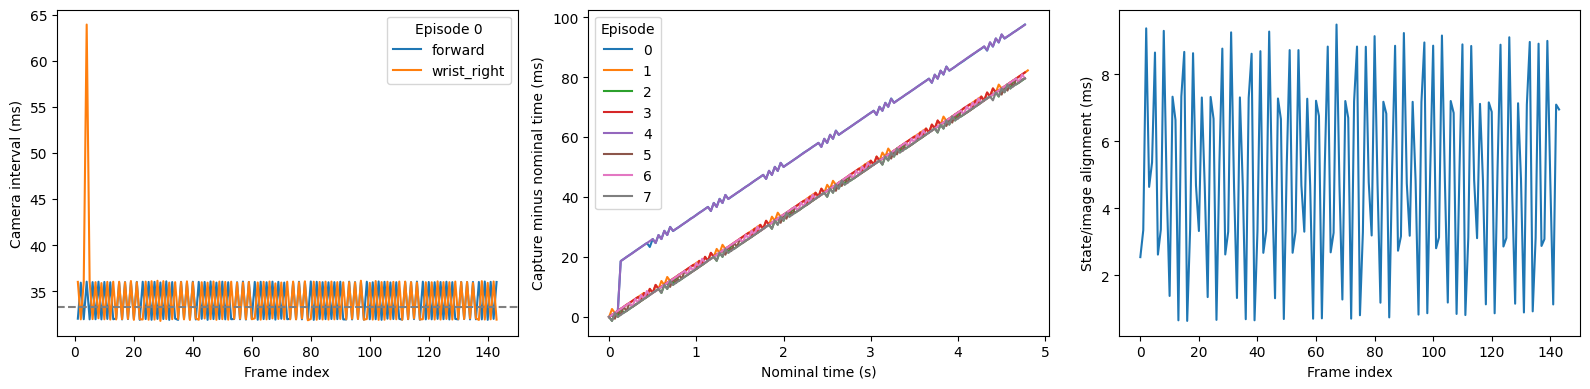

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from alohamini.learning.data import capture_timeline

# 检查原始记录，不先过滤或跨 episode 计算间隔。
INSPECT_EPISODE = 0  # 查看此回合的逐相机间隔和配对；累计漂移展示所有回合。
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for episode in range(report['summary']['episodes']):
    timing = capture_timeline(settings['dataset'], episode)
    print(f"Episode {episode}: {len(timing['frame_index'])} 帧, "
          f"目标 {timing['fps']} FPS, 首尾实测 {timing['measured_fps']:.2f} FPS")
    if episode == INSPECT_EPISODE:
        for camera, intervals in timing['camera_intervals_s'].items():
            axes[0].plot(timing['frame_index'][1:], intervals * 1000, label=camera)
        axes[2].plot(timing['frame_index'], timing['alignment_error_s'] * 1000)
    axes[1].plot(timing['nominal_time_s'], timing['drift_s'] * 1000, label=str(episode))
    if episode == INSPECT_EPISODE:
        axes[0].axhline(1000 / timing['fps'], color='gray', linestyle='--')
axes[0].set(xlabel='Frame index', ylabel='Camera interval (ms)')
axes[1].set(xlabel='Nominal time (s)', ylabel='Capture minus nominal time (ms)')
axes[2].set(xlabel='Frame index', ylabel='State/image alignment (ms)')
axes[0].legend(title=f'Episode {INSPECT_EPISODE}')
axes[1].legend(title='Episode')
plt.tight_layout()
plt.show()

### 构建训练样本

本例通过 chunk_size 选择当前图像、可选 state 和后续 action chunk。AlohaMiniDataset 按所选字段筛选可用起点，不删除原始行；缺测电流不会切断有效的 action 序列。回合及明确的控制中断才限制窗口并使用 padding，原因可查 samples.boundaries。其他策略可用 delta_indices 分别选择各字段的历史与未来行；不指定窗口时返回单帧。

ACT／AM-ACT 按标称 FPS 理解 chunk 时间；这里不插值、不重采样，原始时间戳也不自动作为模型输入。检查报告会随 checkpoint 保存。

In [4]:
from alohamini.learning.data import AlohaMiniDataset

samples = AlohaMiniDataset(
    settings['dataset'], episodes=settings['train_episodes'],
    chunk_size=settings['model']['chunk_size'], state=settings['state'],
    cameras=settings.get('cameras'), image_size=tuple(settings['image_size']),
)
print('保留样本:', len(samples), '排除样本:', samples.excluded)
print('输入:', samples.input_features)
print('action 顺序:', samples.info['features']['action']['names'])
print('state 单位:', samples.selection.units if samples.selection else '纯视觉，无 state')
print('首个 chunk padding:', samples[0]['action_is_pad'])

Dataset has 10 warning(s): SAFETY_CAMERA_GAP, SAFETY_CAPTURE_TIMEBASE. Continuing with sample filtering; timestamps are not resampled. Full report is available as samples.report.


保留样本: 1009 排除样本: 0
输入: {'observation.images.forward': PolicyFeature(type='VISUAL', shape=(3, 480, 640)), 'observation.images.wrist_right': PolicyFeature(type='VISUAL', shape=(3, 480, 640))}
action 顺序: ['arm_left_shoulder_pan.pos', 'arm_left_shoulder_lift.pos', 'arm_left_elbow_flex.pos', 'arm_left_wrist_flex.pos', 'arm_left_wrist_yaw.pos', 'arm_left_wrist_roll.pos', 'arm_left_gripper.pos', 'arm_right_shoulder_pan.pos', 'arm_right_shoulder_lift.pos', 'arm_right_elbow_flex.pos', 'arm_right_wrist_flex.pos', 'arm_right_wrist_yaw.pos', 'arm_right_wrist_roll.pos', 'arm_right_gripper.pos', 'x.vel', 'y.vel', 'theta.vel', 'lift_axis.height_mm']
state 单位: 纯视觉，无 state
首个 chunk padding: tensor([False, False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True])


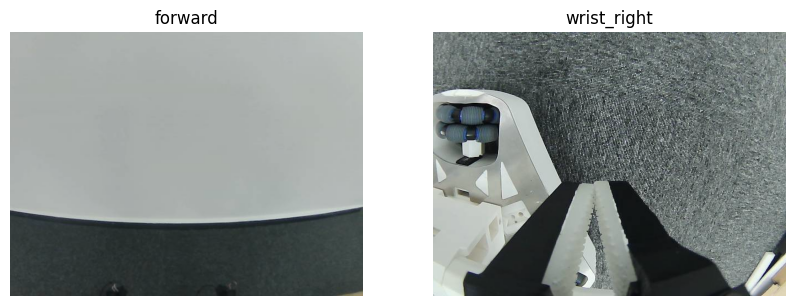

In [5]:
observation = samples.observation(0)
fig, axes = plt.subplots(1, len(samples.cameras), squeeze=False, figsize=(10, 4))
for axis, camera in zip(axes[0], samples.cameras):
    axis.imshow(observation[f'observation.images.{camera}'].permute(1, 2, 0).numpy())
    axis.set_title(camera)
    axis.axis('off')
plt.show()

## 2. 真实反馈：速度与电流

查看肩关节速度与电流，不要求它们成为模型输入。只使用有效反馈，速度单位沿用关节坐标单位/秒，电流为 A；电流不等同于力矩。没有这些字段的数据可跳过本节。

Dataset has 10 warning(s): SAFETY_CAMERA_GAP, SAFETY_CAPTURE_TIMEBASE. Continuing with sample filtering; timestamps are not resampled. Full report is available as samples.report.


反馈保留/排除: 1009 0


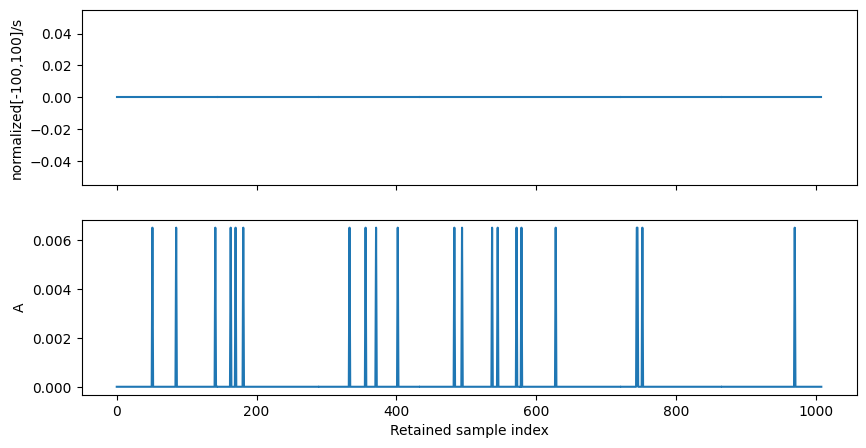

In [6]:
feedback = AlohaMiniDataset(
    settings['dataset'], episodes=settings['train_episodes'], chunk_size=1,
    state='joint_velocity,joint_current', cameras=settings.get('cameras'),
    image_size=tuple(settings['image_size']),
)
names = feedback.selection.feature['names']
values = np.full((len(feedback.rows), len(names)), np.nan)
for row_index in feedback.sample_indices:
    values[row_index] = feedback.selection.frame(feedback.rows[row_index])
joint = 'arm_left_shoulder_lift'
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for axis, suffix in zip(axes, ['vel', 'current_a']):
    column = names.index(f'{joint}.{suffix}')
    # 缺测行保留 NaN；回合和控制边界断开曲线。
    curve = values[:, column].copy()
    for i in range(1, len(curve)):
        if feedback.segment_starts[i] == i:
            curve[i] = np.nan
    axis.plot(curve)
    axis.set_ylabel(feedback.selection.units[column])
axes[-1].set_xlabel('Recorded row index')
print('反馈保留/排除:', len(feedback), feedback.excluded)
plt.show()

## 3. 一个 batch 的前向、损失与梯度

state 可选 `none`（纯视觉）、`joint_position,base_velocity,lift_height` 或 `joint_velocity,joint_current`。统计只来自训练 episode；本单元检查前向与反向，不更新权重。

训练配置中的 chunk_size 决定预测序列长度；视觉骨干默认用 ImageNet 预训练 ResNet18，首次使用从 PyTorch 下载到工作区的 pretrained/，后续复用，不需要 Hugging Face 账号。设 pretrained_backbone_weights=null 才是随机初始化。执行几步后重新推理、是否融合，放在最后的评估单元选择。

In [7]:
import torch
from torch.utils.data import DataLoader
from alohamini.learning.policy import Processor, make_policy

stats = samples.statistics()
model_options = dict(settings['model'])
# 训练前向仍预测完整 chunk；这里只给执行队列提供合法默认值。
model_options.setdefault('n_action_steps', model_options.get('chunk_size', 100))
model_options.update(input_features=samples.input_features, output_features=samples.output_features)
model = make_policy(settings['policy'], model_options, stats).to(settings['device'])
processor = Processor(stats, settings['device'])
batch = next(iter(DataLoader(samples, batch_size=2)))
print({key: tuple(value.shape) for key, value in batch.items()})
loss, metrics = model(processor(batch))
assert torch.isfinite(loss), '损失不是有限值，请检查输入和模型配置。'
loss.backward()
print('loss:', float(loss.detach()), metrics)
model.zero_grad(set_to_none=True)
del model, processor, batch, loss

{'observation.images.forward': (2, 3, 480, 640), 'observation.images.wrist_right': (2, 3, 480, 640), 'action': (2, 30, 18), 'action_is_pad': (2, 30)}
loss: 69.07304382324219 {'l1_loss': 0.770193338394165, 'kld_loss': 6.83028507232666}


## 4. 后台训练

将配置单元中的 RUN_TRAINING 改为 True 后运行本单元。训练在后台进行，关闭 Notebook 不会中断；日志和 PID 保存在工作区。每次实验使用新的 run_name。单 episode 调试可在配置中设 overfit_smoke=true，不作为泛化评估。

In [10]:
from alohamini.learning.train import launch_training

if RUN_TRAINING:
    job = launch_training(settings)
    CHECKPOINT = Path(job['checkpoint'])
    print(job)
    print('tail -f', job['log'])
else:
    print('未启动训练。检查配置后设置 RUN_TRAINING=True。')

{'pid': 61427, 'log': '/home/anncatto/Alohamini_workspace/logs/training/act_local_01.log', 'pid_file': '/home/anncatto/Alohamini_workspace/logs/training/act_local_01.pid', 'config': '/home/anncatto/Alohamini_workspace/logs/training/act_local_01.json', 'checkpoint': '/home/anncatto/Alohamini_workspace/runs/act_local_01/checkpoint'}
tail -f /home/anncatto/Alohamini_workspace/logs/training/act_local_01.log


## 5. Checkpoint 离线推理与示教轨迹对比

训练完成后，用 checkpoint 对当前 observation 预测未来 action，与示教目标对比。横轴是标称时间；曲线不是机器人实际运动轨迹。独立验证 episode 用于计算 MAE。

In [ ]:
from alohamini.learning.policy import NativePolicy
from alohamini.learning.train import offline_evaluate

if CHECKPOINT.exists():
    policy = NativePolicy(CHECKPOINT, device=settings['device'])
    sample = samples[0]
    prediction = policy.predict(sample).numpy()
    valid = ~sample['action_is_pad'].numpy()
    names = samples.info['features']['action']['names']
    columns = [names.index('arm_left_shoulder_lift.pos'), names.index('arm_left_elbow_flex.pos')]
    fig, axes = plt.subplots(len(columns), 1, figsize=(10, 5))
    for axis, column in zip(axes, columns):
        axis.plot(np.flatnonzero(valid) / samples.info['fps'], sample['action'].numpy()[valid, column], label='demonstration')
        axis.plot(np.flatnonzero(valid) / samples.info['fps'], prediction[valid, column], label='prediction')
        axis.set_title(names[column])
        axis.legend()
    axes[-1].set_xlabel('Nominal future time (s)')
    plt.show()
    if settings.get('val_episodes'):
        validation = AlohaMiniDataset(
            settings['dataset'], episodes=settings['val_episodes'],
            chunk_size=policy.config.chunk_size, state=settings['state'],
            cameras=policy.manifest['cameras'], image_size=tuple(settings['image_size']),
        )
        print(offline_evaluate(policy, validation))
    else:
        print('没有独立验证集；此图不能证明泛化或任务成功率。')
else:
    print('Checkpoint 尚不存在:', CHECKPOINT)

## 6. 真机评估（可选）

设置 HOST 和 ENABLE_ROBOT=True 才连接机器人。使用已验证的 checkpoint，确认相机、标定和工作空间，准备随时停止；不要直接部署仅做过几步流程测试的权重。执行由平台 evaluator 完成。

n_action_steps 表示执行几步后重新预测，必须不超过 checkpoint 的 chunk_size。temporal_ensemble_coeff=None 关闭融合；启用融合（例如 0.01）时，n_action_steps 必须为 1。这些选择不需要重新训练。删除对应字典项则沿用 checkpoint 默认值。

In [ ]:
from alohamini.learning.policy import evaluate_robot

execution_options = {
    'n_action_steps': 10,
    'temporal_ensemble_coeff': None,
}
# 每步重预测并融合：execution_options = dict(n_action_steps=1, temporal_ensemble_coeff=0.01)
if ENABLE_ROBOT:
    evaluate_robot(CHECKPOINT, enable_robot=True, host=HOST,
                   device=settings['device'], episode_time_s=10, num_episodes=1,
                   **execution_options)
else:
    print('真机评估未启用；没有建立机器人连接。')